# Model 3 — Cache Modeling

**Question Answered:** _The ROI of cache optimization on effective cost per inference._

**Question:** What is a point of cache-hit rate worth, in effective cost per inference and in annual dollars?

_Builds on Model 2's cost-per-inference baseline._

## 1. Inputs & Assumptions

- **Source:** `inference_events` (`cache_hit`) joined to `cost_constants`.
- **Cache economics:** a cache hit serves the request at a fraction of full compute. We assume a hit costs **15%** of a miss (`HIT_COST_FRACTION = 0.15`) — consistent with typical prompt-cache pricing.
- **Effective cost:** `eff(hr) = hr·0.15·c_miss + (1−hr)·c_miss`, where `c_miss` is the full-compute cost per inference and `hr` is the cache-hit rate.
- **Production scale (assumption):** the 120K-event sample is scaled to a representative **1 billion inferences/day → 365B/yr** to express savings in business terms. The *percentage* results are scale-free.
- Current blended hit rate is ~33%.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.figsize':(9,4.5),'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})
NAVY, AMBER, GREY = '#1F3864', '#E1A140', '#9AA5B1'

conn = sqlite3.connect('../data/events.db')
pd.set_option('display.float_format', lambda v: f'{v:,.6f}')
print('rows:', pd.read_sql_query('SELECT COUNT(*) n FROM inference_events', conn).n[0])

rows: 120000


## 2. Working Code

### 2a. Full-compute (miss) cost baseline and current hit rate (query Q3)

In [2]:
q = '''
SELECT e.workload_type, e.cache_hit,
       e.gpu_seconds * c.blended_cost_per_gpu_second AS cost_per_inference
FROM inference_events e
JOIN cost_constants c USING (gpu_type)
'''
d = pd.read_sql_query(q, conn)
c_miss  = d.cost_per_inference.mean()        # full-compute reference
cur_hr  = pd.read_sql_query('SELECT AVG(cache_hit) hr FROM inference_events', conn).hr[0]
print(f'current cache-hit rate: {cur_hr:.1%}')
print(f'full-compute cost per inference (c_miss): ${c_miss:.6f}')

current cache-hit rate: 33.2%
full-compute cost per inference (c_miss): $0.000073


### 2b. Effective cost-per-inference curve vs cache-hit rate

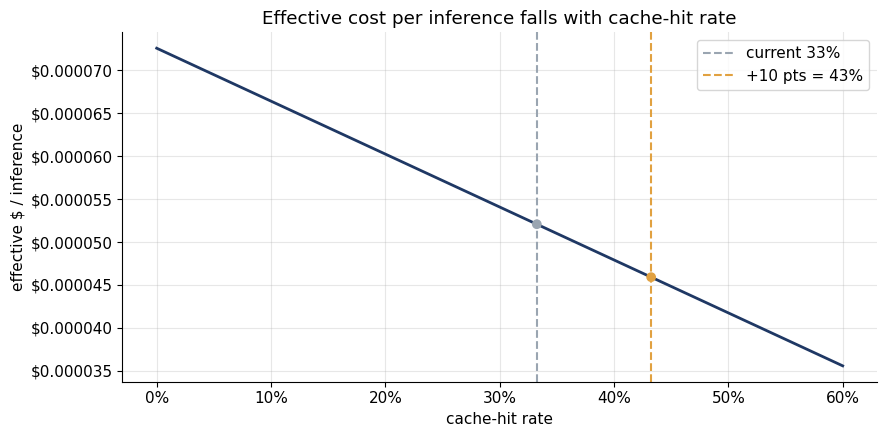

In [3]:
HIT_COST_FRACTION = 0.15
def eff(hr): return (hr*HIT_COST_FRACTION + (1-hr)) * c_miss

hr_grid = np.linspace(0, 0.6, 61)
fig, ax = plt.subplots()
ax.plot(hr_grid, [eff(h) for h in hr_grid], color=NAVY, lw=2)
ax.axvline(cur_hr, color=GREY, ls='--', label=f'current {cur_hr:.0%}')
ax.axvline(cur_hr+0.10, color=AMBER, ls='--', label=f'+10 pts = {cur_hr+0.10:.0%}')
ax.scatter([cur_hr, cur_hr+0.10],[eff(cur_hr), eff(cur_hr+0.10)], color=[GREY,AMBER], zorder=5)
ax.set_xlabel('cache-hit rate'); ax.set_ylabel('effective $ / inference')
ax.set_title('Effective cost per inference falls with cache-hit rate')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.6f')); ax.legend()
plt.tight_layout(); plt.show()

### 2c. ROI of a 10-point cache improvement

In [4]:
pct_reduction = 100*(1 - eff(cur_hr+0.10)/eff(cur_hr))
ANNUAL_INFERENCES = 1_000_000_000 * 365      # 1B/day production assumption
annual_now  = eff(cur_hr)        * ANNUAL_INFERENCES
annual_plus = eff(cur_hr+0.10)   * ANNUAL_INFERENCES
savings = annual_now - annual_plus
print(f'+10 pts cache-hit  -> {pct_reduction:.1f}% lower effective cost per inference')
print(f'annual compute @ {cur_hr:.0%} hit : ${annual_now:,.0f}')
print(f'annual compute @ {cur_hr+0.10:.0%} hit : ${annual_plus:,.0f}')
print(f'annual savings from +10 pts        : ${savings:,.0f}')

steps = pd.DataFrame({'hit_rate':[0.20,0.30,0.40,0.50,0.60]})
steps['eff_cost'] = steps.hit_rate.map(eff)
steps['annual_$'] = steps.eff_cost*ANNUAL_INFERENCES
steps

+10 pts cache-hit  -> 11.8% lower effective cost per inference
annual compute @ 33% hit : $19,007,983
annual compute @ 43% hit : $16,755,862
annual savings from +10 pts        : $2,252,120


,hit_rate,eff_cost,annual_$
0,0.200000,0.000060,"21,991,291.024111"
1,0.300000,0.000054,"19,739,170.858991"
2,0.400000,0.000048,"17,487,050.693871"
3,0.500000,0.000042,"15,234,930.528751"
4,0.600000,0.000036,"12,982,810.363632"


## 3. Insight

> **Cache-hit rate is a first-order compute-spend lever with a clean ROI.** From the current **~33%** hit rate, each **+10 points** lowers effective cost per inference by **~11.8%**. Scaled to a representative **1B inferences/day**, that single 10-point improvement is worth **~$2.25M per year** — a concrete return to weigh against the engineering cost of better prompt/KV-cache reuse.

**Why it matters:** unlike batching (Model 2), cache gains are *not* bounded by the latency SLO — a hit is both cheaper **and** faster. That makes cache optimisation the highest-quality ROI lever in the stack.

**Frames the ask:** "+10 points of cache = $2.25M/yr" is exactly the form of ROI statement the JD's compute-spend framework calls for.